In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from time import perf_counter
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier

from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd

from src import experiment_tracking


| Parâmetro           |  Valor | Função                                                 |
| ------------------- | -----: | ------------------------------------------------------ |
| `n_estimators`      |    200 | Quantidade de árvores da floresta                      |
| `criterion`         | `gini` | Critério utilizado para escolher as divisões           |
| `max_depth`         |     20 | Limita a profundidade máxima das árvores               |
| `min_samples_split` |     10 | Exige pelo menos 10 observações para dividir um nó     |
| `min_samples_leaf`  |      5 | Exige pelo menos 5 observações em cada folha           |
| `max_features`      | `sqrt` | Cada divisão analisa uma parte aleatória das variáveis |
| `bootstrap`         | `True` | Cada árvore recebe uma amostra com reposição           |
| `class_weight`      | `None` | Não atribui peso adicional às fraudes                  |
| `n_jobs`            |   `-1` | Utiliza todos os núcleos disponíveis                   |
| `random_state`      |     42 | Torna o resultado reproduzível                         |


In [8]:
threshold_inicial_value = 0.50

n_estimators_value=200,
criterion_value="gini",
max_depth_value=20,
min_samples_split_value=10,
min_samples_leaf_value=5,
max_features_value="sqrt",
bootstrap_value=True,
class_weight_value=None,
n_jobs_value=-1,
random_state_value=42

In [9]:
df = pd.read_csv("../raw/fraudTrain.csv", parse_dates = ["trans_date_trans_time", "dob"], dtype = {"cc_num": "string", "trans_num": "string", "zip": "string"})

In [10]:

modelo_random_forest = RandomForestClassifier(
    n_estimators=n_estimators_value,
    criterion=criterion_value,
    max_depth=max_depth_value,
    min_samples_split=min_samples_split_value,
    min_samples_leaf=min_samples_leaf_value,
    max_features=max_features_value,
    bootstrap=bootstrap_value,
    class_weight=class_weight_value,
    n_jobs=n_jobs_value,
    random_state=random_state_value
)

In [11]:
parametros_random_forest = {
    "n_estimators":n_estimators_value,
    "criterion":criterion_value,
    "max_depth":max_depth_value,
    "min_samples_split":min_samples_split_value,
    "min_samples_leaf":min_samples_leaf_value,
    "max_features":max_features_value,
    "bootstrap":bootstrap_value,
    "class_weight":class_weight_value,
    "n_jobs":n_jobs_value,
    "random_state":random_state_value,
    "threshold":threshold_inicial_value
}

nome_experimento = (
    "random_forest_none_"
    "n200_d20_leaf5_threshold_050"
)

observacao = (
    "Primeira execução da Random Forest. "
    "Mesmas features e separação temporal utilizadas "
    "na baseline de Regressão Logística. "
    "Sem ponderação das classes."
)

In [12]:
# Removendo a coluna de índice
colunas_sem_nome = [coluna for coluna in df.columns if coluna.startswith("Unnamed")]

df = df.drop(columns=colunas_sem_nome)

In [13]:
# Ordenando de maneira cronológica
df = (df.sort_values("trans_date_trans_time").reset_index(drop = True))

print(f"Linhas: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
print(f"Início: {df['trans_date_trans_time'].min()}")
print(f"Fim: {df['trans_date_trans_time'].max()}")

Linhas: 1,296,675
Colunas: 22
Início: 2019-01-01 00:00:18
Fim: 2020-06-21 12:13:37


In [14]:

CAMINHO_RESULTADOS = Path(
    "../outputs/resultados_modelos_random_forest.csv"
)


def salvar_resultado_experimento(
    resultado,
    nome_modelo: str,
    nome_experimento: str,
    parametros: dict ,
    conjunto_features: str = "",
    observacoes: str = "",
    tempo_treinamento_segundos: float = "",
    caminho: Path = CAMINHO_RESULTADOS
) -> pd.DataFrame:
    """
    Salva uma execução do modelo em um arquivo CSV.

    Cada linha do arquivo representa um experimento.
    """

    caminho.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    # Aceita tanto um DataFrame de uma linha quanto um dicionário.
    if isinstance(resultado, pd.DataFrame):
        if len(resultado) != 1:
            raise ValueError(
                "O DataFrame de resultado deve possuir exatamente uma linha."
            )

        registro = resultado.iloc[0].to_dict()

    elif isinstance(resultado, dict):
        registro = resultado.copy()

    else:
        raise TypeError(
            "resultado deve ser um DataFrame de uma linha ou um dicionário."
        )

    metadados = {
        "data_execucao": datetime.now().isoformat(
            timespec="seconds"
        ),
        "nome_experimento": nome_experimento,
        "nome_modelo": nome_modelo,
        "conjunto_features": conjunto_features,
        "parametros": json.dumps(
            parametros or {},
            ensure_ascii=False,
            sort_keys=True
        ),
        "tempo_treinamento_segundos": (
            tempo_treinamento_segundos
        ),
        "observacoes": observacoes
    }

    registro_completo = {
        **metadados,
        **registro
    }

    nova_linha = pd.DataFrame(
        [registro_completo]
    )

    arquivo_ja_existe = caminho.exists()

    nova_linha.to_csv(
        caminho,
        mode="a",
        header=not arquivo_ja_existe,
        index=False,
        encoding="utf-8-sig"
    )

    print(
        f"Experimento salvo em: {caminho.resolve()}"
    )

    return nova_linha

In [15]:
def calcular_distancia_km(
        lat_cliente: pd.Series,
        lon_cliente: pd.Series,
        lat_estabelecimento: pd.Series,
        lon_estabelecimento: pd.Series
) -> np.ndarray:
    """
    Calcula a distancia entre dois pontos geográficos utilizando a fórmula de Haversine.
    """

    raio_terra_km = 6371.0088

    lat1 = np.radians(lat_cliente.to_numpy())
    lon1 = np.radians(lon_cliente.to_numpy())
    lat2 = np.radians(lat_estabelecimento.to_numpy())
    lon2 = np.radians(lon_estabelecimento.to_numpy())

    delta_lat = lat2 - lat1
    delta_lon  = lon2 - lon1

    a = (np.sin(delta_lat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(delta_lon / 2) ** 2 )

    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return raio_terra_km * c

In [16]:
def criar_features(dados: pd.DataFrame) -> pd.DataFrame:
    """
    Cria as variáveis utilizadas pela Regressão Logística.
    
    Todas as variáveis são construídas usando apenas informações da própria transação.
    """

    features = pd.DataFrame(index = dados.index)

    data_transacao = dados["trans_date_trans_time"]
    data_nascimento = dados["dob"]

    # Valor da transação em escala logarítmica
    features["amt_log"] = np.log1p(dados["amt"])

    # População também apresenta assimetria
    features["city_pop_log"] = np.log1p(dados["city_pop"])

    # Idade exata na data da transação
    aniversario_ainda_nao_ocorreu = (data_transacao.dt.month < data_nascimento.dt.month) | ((data_transacao.dt.month == data_nascimento.dt.month) & (data_transacao.dt.day < data_nascimento.dt.day))

    features["idade"] = (
        data_transacao.dt.year - data_nascimento.dt.year - aniversario_ainda_nao_ocorreu.astype(int)
    )

    # Distância aproximada entre cliente e estabelecimento
    features["distancia_km"] = calcular_distancia_km(
        dados["lat"],
        dados["long"],
        dados["merch_lat"],
        dados["merch_long"]
    )

    # Variáveis temporais cíclicas
    hora = data_transacao.dt.hour

    features["hora_sin"] = np.sin(
        2 * np.pi * hora / 24
    )

    features["hora_cos"] = np.cos(
        2 * np.pi * hora / 24
    )

    dia_semana = data_transacao.dt.dayofweek

    features["dia_semana_sin"] = np.sin(
        2 * np.pi * dia_semana / 7
    )
    
    features["dia_semana_cos"] = np.cos(
        2 * np.pi * dia_semana / 7
    )

    features["fim_de_semana"] = (
        dia_semana >= 5
    ).astype(int)

    # variáveis categóricas
    features["category"] = dados["category"].astype("string")
    features["gender"] = dados["gender"].astype("string")
    features["state"] = dados["state"].astype("string")

    return features

In [17]:
# Separação temporal
# 70% dos dados mais antigos -> treino
# 15% seguinte -> validação
# 15% mais recente -> teste

limite_treino = int(len(df) * 0.7)
limite_validacao = int(len(df) * 0.85)

df_treino = df.iloc[:limite_treino].copy()

df_validacao = df.iloc[limite_treino:limite_validacao].copy()

df_teste = df.iloc[limite_validacao:].copy()

In [18]:
# criando as features
X_treino = criar_features(df_treino)
X_validacao = criar_features(df_validacao)
X_teste = criar_features(df_teste)

y_treino = df_treino["is_fraud"].astype(int)
y_validacao = df_validacao["is_fraud"].astype(int)
y_teste = df_teste["is_fraud"].astype(int)

In [19]:
def resumo_particao(nome: str, dados: pd.DataFrame, target: pd.Series) -> dict:
    return {
        "particao": nome,
        "inicio": dados["trans_date_trans_time"].min(), 
        "fim": dados["trans_date_trans_time"].max(),
        "transacoes": len(dados),
        "fraudes": int(target.sum()),
        "taxa_fraude_percentual": target.mean() * 100
    }

resumo_particoes = pd.DataFrame([
    resumo_particao("Treino", df_treino, y_treino),
    resumo_particao("Validação", df_validacao, y_validacao),
    resumo_particao("Teste", df_teste, y_teste)
])

In [20]:
experimento = experiment_tracking.iniciar_experimento(
    nome_experimento
)

parametros_experimento = {
    "modelo": "RandomForestClassifier",
    "n_estimators": n_estimators_value,
    "criterion": criterion_value,
    "max_depth": max_depth_value,
    "min_samples_split": min_samples_split_value,
    "min_samples_leaf": min_samples_leaf_value,
    "max_features": max_features_value,
    "bootstrap": bootstrap_value,
    "class_weight": class_weight_value,
    "n_jobs": -1,
    "threshold": threshold_inicial_value,
    "random_state": random_state_value,
    "split": "temporal_70_15_15",
    "features": [
        "amt_log",
        "city_pop_log",
        "idade",
        "distancia_km",
        "hora_sin",
        "hora_cos",
        "dia_semana_sin",
        "dia_semana_cos",
        "fim_de_semana",
        "category",
        "gender",
        "state"
    ]
}

experiment_tracking.salvar_json(
    parametros_experimento,
    experimento["pasta_run"] / "parametros.json"
)

Experimento criado: 20260801_005026__random_forest_none_n200_d20_leaf5_threshold_050
Pasta: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/experiments/20260801_005026__random_forest_none_n200_d20_leaf5_threshold_050


In [21]:
# variaveis que serão utilizadas

variaveis_numericas = [
    "amt_log",
    "city_pop_log",
    "idade",
    "distancia_km",
    "hora_sin",
    "hora_cos",
    "dia_semana_sin",
    "dia_semana_cos",
    "fim_de_semana"
]

variaveis_categoricas = [
   "category",
   "gender",
   "state"
]

In [22]:
modelo_random_forest = RandomForestClassifier(
    n_estimators = 200,
    criterion="gini",
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap = True,\
    class_weight=None,
    n_jobs = -1,
    random_state = 42
)

In [23]:
pipeline_numerico_rf = Pipeline (
    steps = [
        (
            "imputacao",
            SimpleImputer(strategy = "median")
        )
    ]
)

pipeline_categorico_rf = Pipeline(
    steps = [
        (
            "imputacao",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "one_hot",
            OneHotEncoder(
                handle_unknown = "ignore"
            )
        )
    ]
)

In [24]:
preprocessador_rf = ColumnTransformer(
    transformers = [
        (
        "numericas",
        pipeline_numerico_rf,
        variaveis_numericas
    ),
    (
        "categoricas",
        pipeline_categorico_rf,
        variaveis_categoricas
    )
    ],
    remainder="drop"
)

In [25]:
pipeline_random_forest = Pipeline(
    steps = [
        (
            "preprocessamento",
            preprocessador_rf
        ),
        (
            "modelo",
            modelo_random_forest
        )
    ]
)

In [26]:
inicio_treinamento = perf_counter()

pipeline_random_forest.fit(
    X_treino,
    y_treino
)

tempo_treinamento = (
    perf_counter() - inicio_treinamento
)

print(
    f"Tempo de treinamento: {tempo_treinamento:.2f} segundos"
)

Tempo de treinamento: 160.03 segundos


In [27]:
scores_validacao_rf = (
    pipeline_random_forest
    .predict_proba(X_validacao)[:, 1]
)

In [28]:
pd.Series(
    scores_validacao_rf
).describe(
    percentiles = [
        0.50,
        0.90,
        0.95,
        0.99,
        0.995,
        0.999
    ]
)

count    194501.000000
mean          0.006065
std           0.049604
min           0.000011
50%           0.000412
90%           0.005923
95%           0.010005
99%           0.056354
99.5%         0.333554
99.9%         0.810612
max           0.931585
dtype: float64

In [29]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def avaliar_modelo(
    y_real,
    scores,
    threshold
) -> pd.DataFrame:
    """
    Avalia um modelo de classificação binária a partir dos scores
    atribuídos à classe positiva.

    Parâmetros
    ----------
    y_real:
        Classes reais. Espera-se 0 para transação legítima e
        1 para transação fraudulenta.

    scores:
        Probabilidade ou score atribuído à classe de fraude.

        Exemplo:
        modelo.predict_proba(X)[:, 1]

    threshold:
        Ponto de corte utilizado para transformar o score em classe.

        score >= threshold -> fraude
        score < threshold  -> legítima

    Retorno
    -------
    pd.DataFrame:
        DataFrame com uma linha contendo todas as métricas.
    """

    y_real = np.asarray(y_real).ravel()
    scores = np.asarray(scores).ravel()

    if len(y_real) != len(scores):
        raise ValueError(
            "y_real e scores precisam possuir a mesma quantidade "
            "de observações."
        )

    if not 0 <= threshold <= 1:
        raise ValueError(
            "O threshold deve estar entre 0 e 1."
        )

    if not np.isfinite(scores).all():
        raise ValueError(
            "Os scores possuem valores ausentes ou infinitos."
        )

    # Converte o score em uma decisão binária.
    y_previsto = (scores >= threshold).astype(int)

    # labels=[0, 1] garante uma matriz 2x2 mesmo quando alguma
    # classe não é prevista pelo modelo.
    matriz = confusion_matrix(
        y_real,
        y_previsto,
        labels=[0, 1]
    )

    verdadeiros_negativos, falsos_positivos, \
        falsos_negativos, verdadeiros_positivos = matriz.ravel()

    # ROC-AUC exige que existam as duas classes em y_real.
    if np.unique(y_real).size == 2:
        roc_auc = roc_auc_score(y_real, scores)
    else:
        roc_auc = np.nan

    resultado = {
        "threshold": float(threshold),

        # Métricas calculadas diretamente sobre os scores.
        "average_precision": average_precision_score(
            y_real,
            scores
        ),
        "roc_auc": roc_auc,

        # Métricas dependentes do threshold.
        "accuracy": accuracy_score(
            y_real,
            y_previsto
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_real,
            y_previsto
        ),
        "precision_fraude": precision_score(
            y_real,
            y_previsto,
            pos_label=1,
            zero_division=0
        ),
        "recall_fraude": recall_score(
            y_real,
            y_previsto,
            pos_label=1,
            zero_division=0
        ),
        "f1_fraude": f1_score(
            y_real,
            y_previsto,
            pos_label=1,
            zero_division=0
        ),

        # Valores da matriz de confusão.
        "verdadeiros_negativos": int(verdadeiros_negativos),
        "falsos_positivos": int(falsos_positivos),
        "falsos_negativos": int(falsos_negativos),
        "verdadeiros_positivos": int(verdadeiros_positivos),

        # Percentual de transações encaminhadas como fraude.
        "percentual_alertado": y_previsto.mean() * 100
    }

    return pd.DataFrame([resultado])

In [30]:
resultado_random_forest = avaliar_modelo(
    y_validacao,
    scores_validacao_rf,
    threshold = threshold_inicial_value
)

resultado_random_forest.T

,0
threshold,0.500000
average_precision,0.877325
roc_auc,0.991701
accuracy,0.997280
balanced_accuracy,0.792309
precision_fraude,0.987854
recall_fraude,0.584665
f1_fraude,0.734571
verdadeiros_negativos,193240.000000
falsos_positivos,9.000000


In [31]:
nomes_features_rf = (
    pipeline_random_forest
    .named_steps["preprocessamento"]
    .get_feature_names_out()
)

importancias_rf = (
    pipeline_random_forest
    .named_steps["modelo"]
    .feature_importances_
)

In [32]:
tabela_importancias_rf = (
    pd.DataFrame(
        {
            "variavel": nomes_features_rf,
            "importancia": importancias_rf
        }
    )
    .sort_values(
        "importancia",
        ascending=False
    )
)

tabela_importancias_rf.head(20)

,variavel,importancia
0,numericas__amt_log,0.595291
5,numericas__hora_cos,0.068630
4,numericas__hora_sin,0.064501
13,categoricas__category_grocery_pos,0.055887
2,numericas__idade,0.054384
1,numericas__city_pop_log,0.021103
20,categoricas__category_shopping_net,0.016977
11,categoricas__category_gas_transport,0.016164
3,numericas__distancia_km,0.014065
17,categoricas__category_misc_net,0.014037


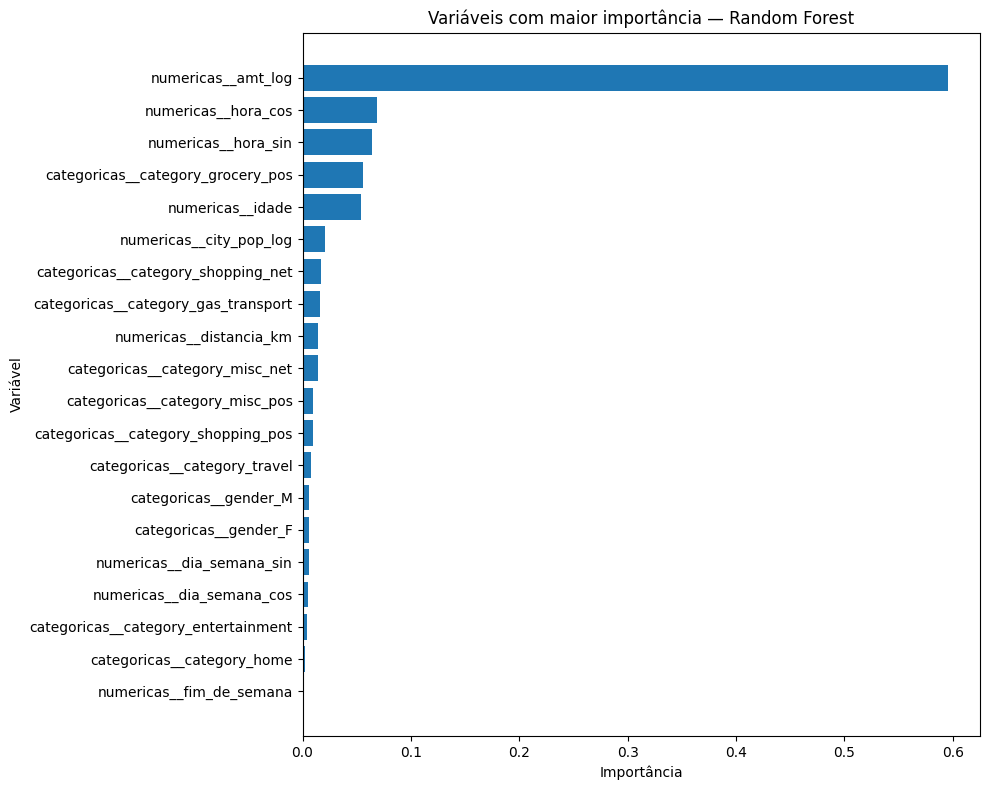

In [33]:
import matplotlib.pyplot as plt

top_importancias_rf = (
    tabela_importancias_rf
    .head(20)
    .sort_values("importancia")
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

ax.barh(
    top_importancias_rf["variavel"],
    top_importancias_rf["importancia"]
)

ax.set_title(
    "Variáveis com maior importância — Random Forest"
)

ax.set_xlabel(
    "Importância"
)

ax.set_ylabel(
    "Variável"
)

plt.tight_layout()
plt.show()

In [36]:
import json
salvar_resultado_experimento(
    resultado=resultado_random_forest,
    nome_modelo="Random Forest",
    nome_experimento=nome_experimento,
    parametros=parametros_experimento,
    conjunto_features="features_basicas_v1",
    tempo_treinamento_segundos=tempo_treinamento,
    observacoes=observacao
)

Experimento salvo em: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/resultados_modelos_random_forest.csv


,data_execucao,nome_experimento,nome_modelo,conjunto_features,parametros,tempo_treinamento_segundos,observacoes,threshold,average_precision,roc_auc,accuracy,balanced_accuracy,precision_fraude,recall_fraude,f1_fraude,verdadeiros_negativos,falsos_positivos,falsos_negativos,verdadeiros_positivos,percentual_alertado
0,2026-08-01T00:55:03,random_forest_none_n200_d20_leaf5_threshold_050,Random Forest,features_basicas_v1,"{""bootstrap"": [true], ""class_weight"": [null], ...",160.028469,Primeira execução da Random Forest. Mesmas fea...,0.5,0.877325,0.991701,0.99728,0.792309,0.987854,0.584665,0.734571,193240.0,9.0,520.0,732.0,0.380975
